# Tugas 2 - Data Lifecycle Management
## Smart Agriculture Dataset

Nama: Btari Adiella Duhita Salsabila  
NPM: 23082010150  
Kelas: Big Data & IoT paralel B

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set()
plt.rcParams["figure.figsize"] = (10, 5)

In [6]:
df = pd.read_csv("data/raw/cropdata_updated.csv")
df.head()

,crop ID,soil_type,Seedling Stage,MOI,temp,humidity,result
0,Wheat,Black Soil,Germination,1,25,80.0,1
1,Wheat,Black Soil,Germination,2,26,77.0,1
2,Wheat,Black Soil,Germination,3,27,74.0,1
3,Wheat,Black Soil,Germination,4,28,71.0,1
4,Wheat,Black Soil,Germination,5,29,68.0,1


In [7]:
df.info()
df.describe(include='all')
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 16411 entries, 0 to 16410
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   crop ID         16411 non-null  str    
 1   soil_type       16411 non-null  str    
 2   Seedling Stage  16411 non-null  str    
 3   MOI             16411 non-null  int64  
 4   temp            16411 non-null  int64  
 5   humidity        16411 non-null  float64
 6   result          16411 non-null  int64  
dtypes: float64(1), int64(3), str(3)
memory usage: 897.6 KB


crop ID           0
soil_type         0
Seedling Stage    0
MOI               0
temp              0
humidity          0
result            0
dtype: int64

In [8]:
# rename kolom
df.columns = [c.strip().lower().replace(" ", "_") for c in df.columns]

# pisahkan kolom numerik & kategorikal
num_cols = df.select_dtypes(include=np.number).columns.tolist()
cat_cols = df.select_dtypes(exclude=np.number).columns.tolist()

# handle missing value
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# hapus duplikat
df = df.drop_duplicates()

# remove outlier
def remove_outliers_iqr(data, columns):
    df_clean = data.copy()
    for col in columns:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        df_clean = df_clean[(df_clean[col] >= lower) & (df_clean[col] <= upper)]
    return df_clean

df_clean = remove_outliers_iqr(df, num_cols)

In [10]:
df_clean = df_clean.reset_index(drop=True)
df_clean["record_time"] = pd.date_range(
    start="2026-01-01",
    periods=len(df_clean),
    freq="h"   # huruf kecil
)
df_clean[["record_time"]].head()

,record_time
0,2026-01-01 00:00:00
1,2026-01-01 01:00:00
2,2026-01-01 02:00:00
3,2026-01-01 03:00:00
4,2026-01-01 04:00:00


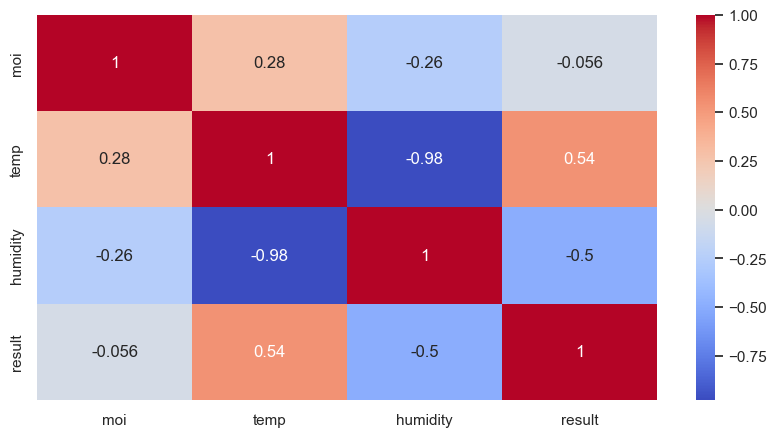

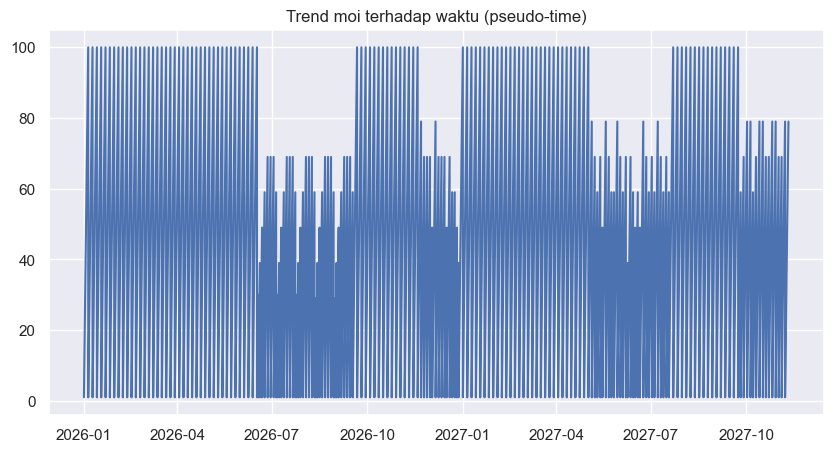

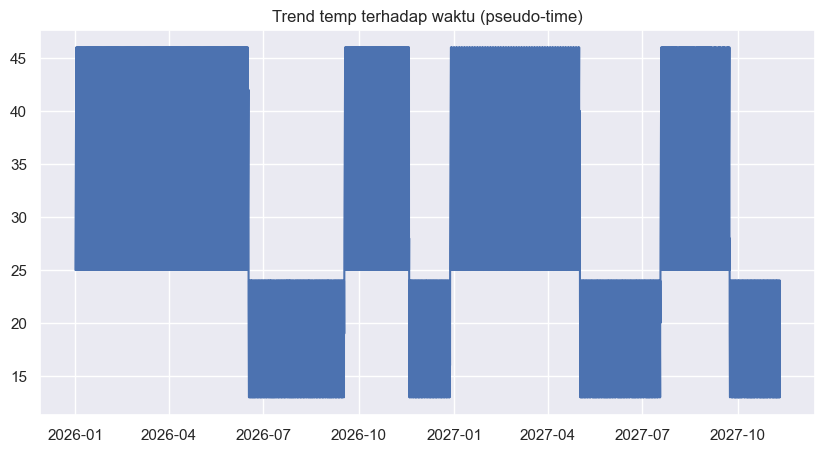

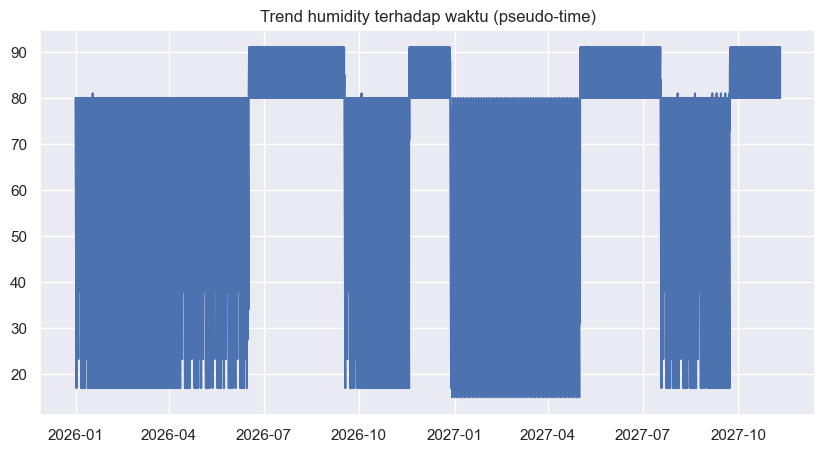

In [11]:
# Heatmap
sns.heatmap(df_clean[num_cols].corr(), annot=True, cmap="coolwarm")
plt.show()

# Time series
for col in ["moi","temp","humidity"]:
    if col in df_clean.columns:
        plt.figure()
        plt.plot(df_clean["record_time"], df_clean[col])
        plt.title(f"Trend {col} terhadap waktu (pseudo-time)")
        plt.show()

In [12]:
os.makedirs("outputs", exist_ok=True)
df_clean.to_csv("outputs/cleaned_data.csv", index=False)

In [15]:
import os

print(os.getcwd())
print(os.path.exists("outputs/cleaned_data.csv"))
print(os.listdir("outputs") if os.path.exists("outputs") else "folder outputs belum ada")

e:\lola\data-lifecycle-smart-agriculture
True
['cleaned_data.csv']


## Data Quality Score
Bagian ini menghitung kualitas data berdasarkan accuracy, completeness, dan timeliness.

In [16]:
import pandas as pd

# pastikan record_time sudah datetime
df_clean["record_time"] = pd.to_datetime(df_clean["record_time"])

# hitung total elemen data
total_cells = df_clean.shape[0] * df_clean.shape[1]
missing_cells = df_clean.isnull().sum().sum()
non_null_cells = total_cells - missing_cells

# 1. Accuracy
accuracy = 1 - (missing_cells / total_cells)

# 2. Completeness
completeness = non_null_cells / total_cells

# 3. Timeliness
latest_time = df_clean["record_time"].max()
cutoff_time = latest_time - pd.Timedelta(days=30)

recent_records = df_clean[df_clean["record_time"] >= cutoff_time].shape[0]
total_records = len(df_clean)

timeliness = recent_records / total_records

# tampilkan hasil
quality_df = pd.DataFrame({
    "Metric": ["Accuracy", "Completeness", "Timeliness"],
    "Score": [accuracy, completeness, timeliness]
})

quality_df["Score"] = quality_df["Score"].round(4)
quality_df

,Metric,Score
0,Accuracy,1.0000
1,Completeness,1.0000
2,Timeliness,0.0443


In [17]:
quality_df.to_csv("outputs/data_quality_score.csv", index=False)
print("data_quality_score.csv berhasil disimpan")

data_quality_score.csv berhasil disimpan
